Loading final dataset...
Visualization fixed (2020 removed)!


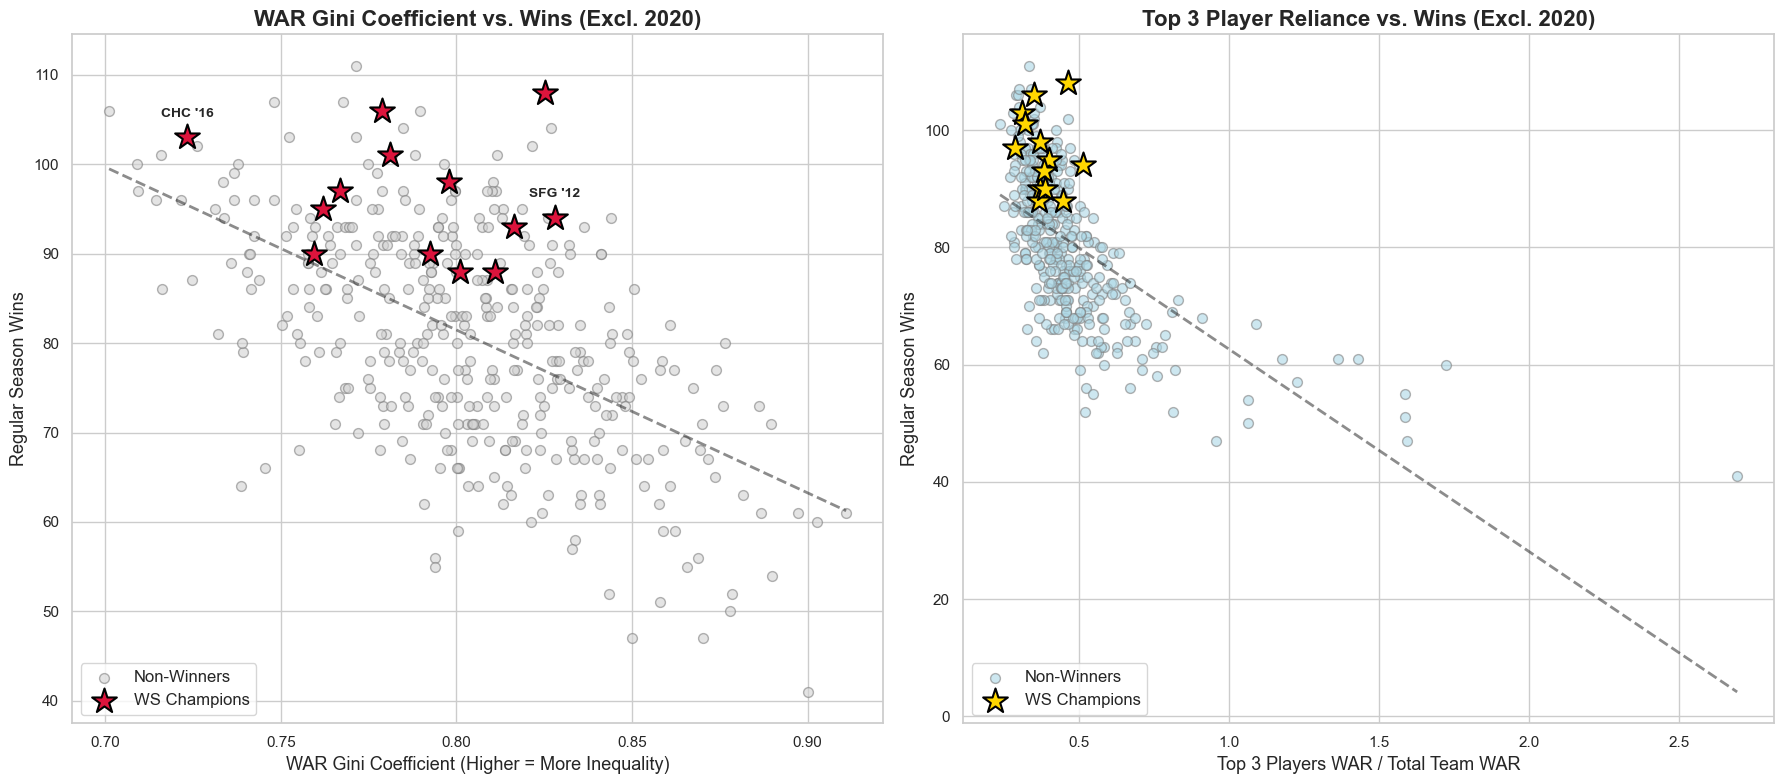

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Loading final dataset...")
df = pd.read_csv('../data/processed_data/final_team_data.csv')

# The 2020 Season dropped: 60-game season breaks the 'Wins' y-axis and WAR accumulations
df = df[df['Season'] != 2020].copy()

# Separate World Series Winners and Non-Winners
ws_winners = df[df['WS_Winner'] == 1]
non_winners = df[df['WS_Winner'] == 0]

# Set up the matplotlib figure (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
sns.set_theme(style="whitegrid")

# Plot 1: WAR Gini Coefficient vs. Regular Season Wins
ax1.scatter(non_winners['Gini_Coefficient'], non_winners['Wins'], 
            color='lightgray', alpha=0.6, edgecolors='gray', s=50, label='Non-Winners')

ax1.scatter(ws_winners['Gini_Coefficient'], ws_winners['Wins'], 
            color='crimson', marker='*', s=350, edgecolors='black', linewidth=1.5, label='WS Champions')

z = np.polyfit(df['Gini_Coefficient'], df['Wins'], 1)
p = np.poly1d(z)
x_range = np.linspace(df['Gini_Coefficient'].min(), df['Gini_Coefficient'].max(), 100)
ax1.plot(x_range, p(x_range), "k--", alpha=0.5, linewidth=2)

ax1.set_title('WAR Gini Coefficient vs. Wins (Excl. 2020)', fontsize=16, fontweight='bold')
ax1.set_xlabel('WAR Gini Coefficient (Higher = More Inequality)', fontsize=13)
ax1.set_ylabel('Regular Season Wins', fontsize=13)
ax1.legend(loc='lower left', fontsize=12)

# Annotate extreme WS winners
min_gini_ws = ws_winners.loc[ws_winners['Gini_Coefficient'].idxmin()]
max_gini_ws = ws_winners.loc[ws_winners['Gini_Coefficient'].idxmax()]
ax1.annotate(f"{min_gini_ws['Team']} '{str(min_gini_ws['Season'])[-2:]}",
             (min_gini_ws['Gini_Coefficient'], min_gini_ws['Wins']),
             textcoords="offset points", xytext=(0,15), ha='center', fontsize=10, fontweight='bold')
ax1.annotate(f"{max_gini_ws['Team']} '{str(max_gini_ws['Season'])[-2:]}",
             (max_gini_ws['Gini_Coefficient'], max_gini_ws['Wins']),
             textcoords="offset points", xytext=(0,15), ha='center', fontsize=10, fontweight='bold')


# Plot 2: Top 3 WAR Reliance vs. Regular Season Wins
ax2.scatter(non_winners['Top3_WAR_Ratio'], non_winners['Wins'], 
            color='lightblue', alpha=0.6, edgecolors='gray', s=50, label='Non-Winners')

ax2.scatter(ws_winners['Top3_WAR_Ratio'], ws_winners['Wins'], 
            color='gold', marker='*', s=350, edgecolors='black', linewidth=1.5, label='WS Champions')

z2 = np.polyfit(df['Top3_WAR_Ratio'], df['Wins'], 1)
p2 = np.poly1d(z2)
x_range2 = np.linspace(df['Top3_WAR_Ratio'].min(), df['Top3_WAR_Ratio'].max(), 100)
ax2.plot(x_range2, p2(x_range2), "k--", alpha=0.5, linewidth=2)

ax2.set_title('Top 3 Player Reliance vs. Wins (Excl. 2020)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Top 3 Players WAR / Total Team WAR', fontsize=13)
ax2.set_ylabel('Regular Season Wins', fontsize=13)
ax2.legend(loc='lower left', fontsize=12)

os.makedirs('../images', exist_ok=True)
save_path = '../images/championship_roster_analysis_fixed.png'
plt.tight_layout()
plt.savefig(save_path, dpi=300)

print("Visualization fixed (2020 removed)!")
plt.show()

Loading final dataset for Positional Scatter Plots...
Positional scatter plots complete! Saved to ../images/positional_scatter_analysis.png


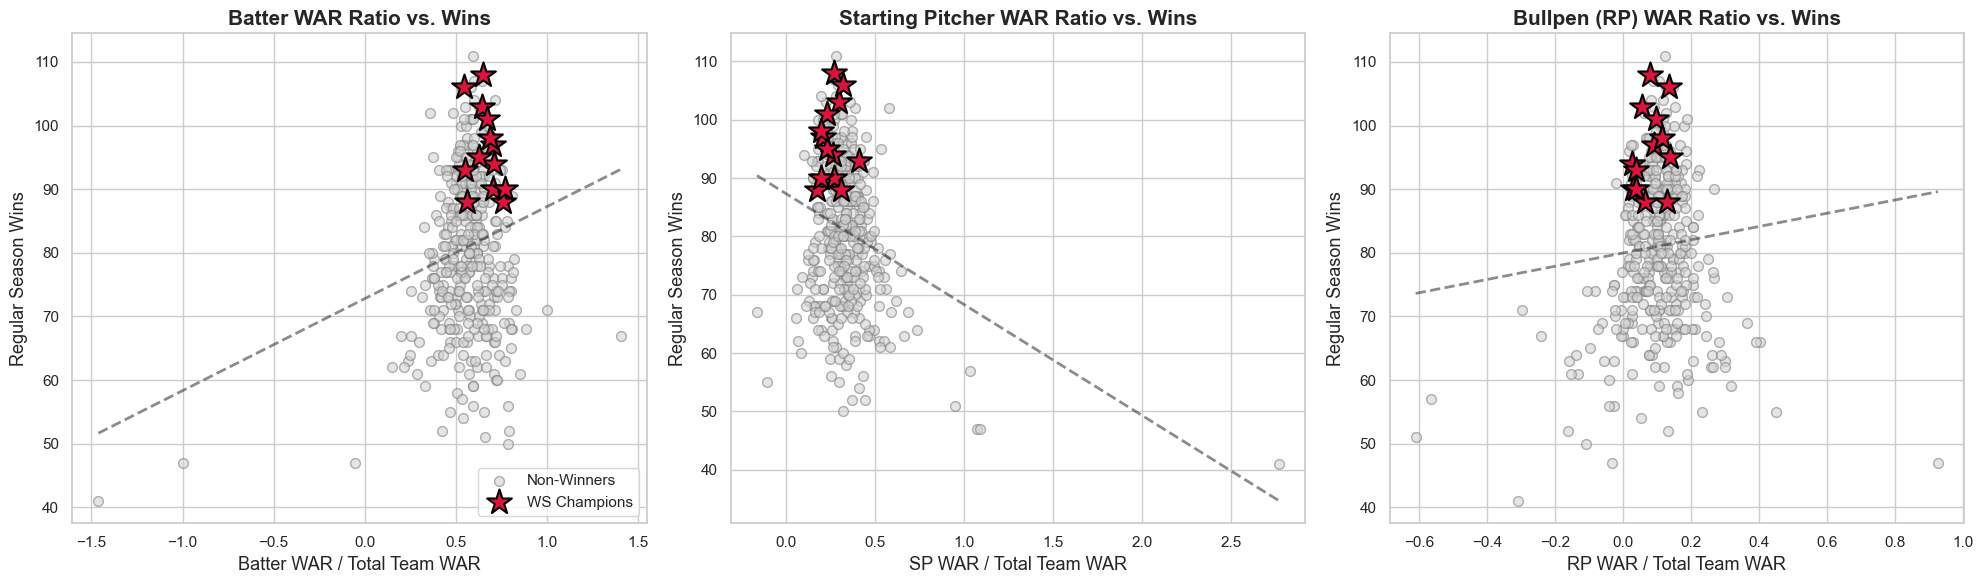

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Loading final dataset for Positional Scatter Plots...")
df = pd.read_csv('../data/processed_data/final_team_data.csv')

# Drop 2020 shortened season (Noise)
df = df[df['Season'] != 2020].copy()

# Ensure Ratios are calculated
df['Batter_Ratio'] = df['Batter_WAR'] / df['Total_WAR']
df['SP_Ratio'] = df['SP_WAR'] / df['Total_WAR']
df['RP_Ratio'] = df['RP_WAR'] / df['Total_WAR']

# Handle rare cases where Total WAR might be 0 to avoid Division by Zero
df = df.fillna(0)

ws_winners = df[df['WS_Winner'] == 1]
non_winners = df[df['WS_Winner'] == 0]

# Set up a 1x3 grid for the plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# Helper function to plot each scatter cleanly
def plot_positional_scatter(ax, feature, title, xlabel):
    # Plot non-winners
    ax.scatter(non_winners[feature], non_winners['Wins'], 
               color='lightgray', alpha=0.6, edgecolors='gray', s=50, label='Non-Winners')
    
    # Plot WS winners as giant stars
    ax.scatter(ws_winners[feature], ws_winners['Wins'], 
               color='crimson', marker='*', s=350, edgecolors='black', linewidth=1.5, label='WS Champions')
    
    # Add trendline
    z = np.polyfit(df[feature], df['Wins'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(df[feature].min(), df[feature].max(), 100)
    ax.plot(x_range, p(x_range), "k--", alpha=0.5, linewidth=2)
    
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel('Regular Season Wins', fontsize=13)

# 1. Batter Ratio
plot_positional_scatter(axes[0], 'Batter_Ratio', 'Batter WAR Ratio vs. Wins', 'Batter WAR / Total Team WAR')
axes[0].legend(loc='lower right', fontsize=11)

# 2. Starting Pitcher Ratio
plot_positional_scatter(axes[1], 'SP_Ratio', 'Starting Pitcher WAR Ratio vs. Wins', 'SP WAR / Total Team WAR')

# 3. Relief Pitcher Ratio
plot_positional_scatter(axes[2], 'RP_Ratio', 'Bullpen (RP) WAR Ratio vs. Wins', 'RP WAR / Total Team WAR')

# Save and display
os.makedirs('../images', exist_ok=True)
save_path = '../images/positional_scatter_analysis.png'
plt.tight_layout()
plt.savefig(save_path, dpi=300)

print(f"Positional scatter plots complete! Saved to {save_path}")
plt.show()